In [1]:
#랜덤포레스트 : 의사결정나무를 개별 모형으로 사용하는 모형 결합 방법
# 독립변수의 차원을 랜덤하게 감소시킨 후 독립변수를 선택하는 방법
import pandas as pd
df = pd.read_csv('c:/data/heart/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [3]:
train_cols = df.columns[0:13]
X = df[train_cols]
y = df['target']

In [4]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['target'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp['target'].value_counts()

target
0    138
1    138
Name: count, dtype: int64

In [5]:
X = df_samp[train_cols]
y = df_samp['target']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
model1 = DecisionTreeClassifier(random_state=0)
model2 = RandomForestClassifier(n_estimators=100, random_state=0)
for model in (model1, model2):
    print(model)
    model.fit(X_train, y_train)
    print('학습용:', model.score(X_train, y_train))
    print('검증용:', model.score(X_test, y_test))
    print()

DecisionTreeClassifier(random_state=0)
학습용: 1.0
검증용: 0.8392857142857143

RandomForestClassifier(random_state=0)
학습용: 1.0
검증용: 0.8928571428571429



In [8]:
#랜덤포레스트의 변종: 익스트림랜덤트리 또는 엑스트라트리 모형
#랜덤포레스트 : 부트스트랩(중복된 샘플)사용, 모든 변수 사용
#엑스트라 트리 : 모든 샘플을 사용, 변수를 랜덤으로 선택
from sklearn.ensemble import ExtraTreesClassifier
model3 = ExtraTreesClassifier(n_estimators=100, random_state=0)
for model in (model1, model2, model3):
    print(model)
    model.fit(X_train, y_train)
    print('학습용:', model.score(X_train, y_train))
    print('검증용:', model.score(X_test, y_test))
    print()

DecisionTreeClassifier(random_state=0)
학습용: 1.0
검증용: 0.8392857142857143

RandomForestClassifier(random_state=0)
학습용: 1.0
검증용: 0.8928571428571429

ExtraTreesClassifier(random_state=0)
학습용: 1.0
검증용: 0.875



In [9]:
# DecisionTree < RandomForest < ExtraTree 순으로 성능이 개선됨

In [10]:
import matplotlib.pyplot as plt
import numpy as np
def plot_tree(model):
    n_features = X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), train_cols)
    plt.xlabel('importances')
    plt.ylabel('variables')
    plt.ylim(-1, n_features)

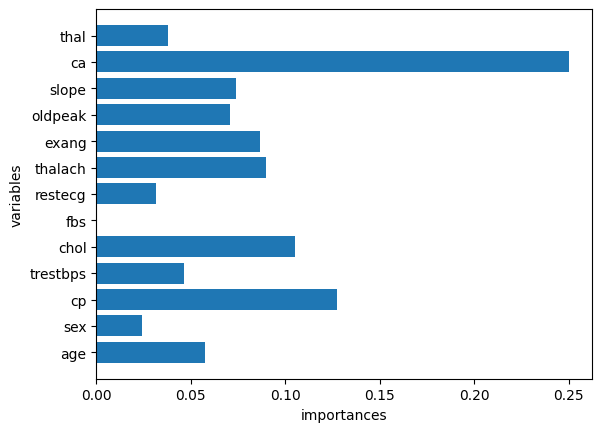

In [11]:
plot_tree(model1)

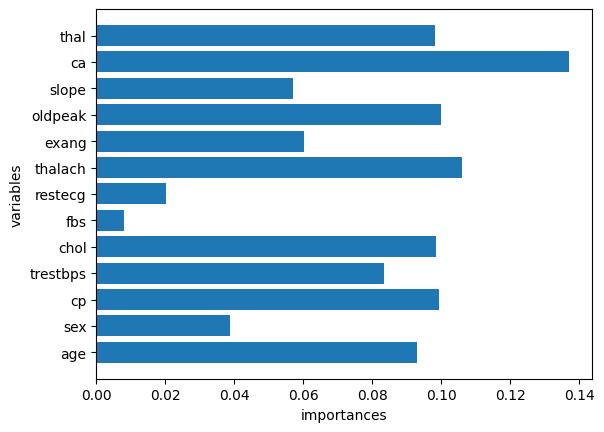

In [12]:
plot_tree(model2)

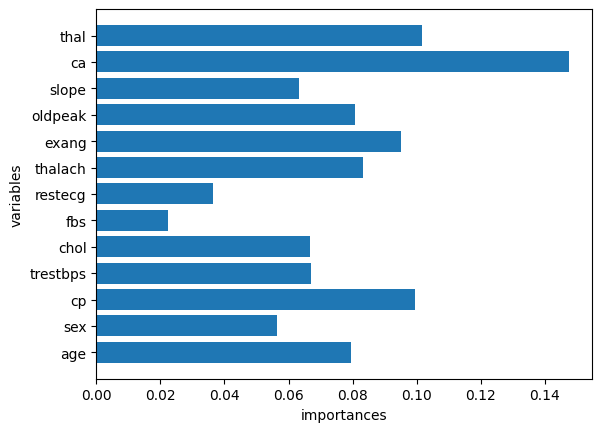

In [13]:
plot_tree(model3)